# Benchmark — Optimizador Multiobjetivo de Layouts

Interfaz interactiva para ejecutar y analizar el benchmark del módulo `mo_module`.  
Configura los parámetros con los controles y pulsa **▶ Ejecutar benchmark**.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

from src.mo_module.benchmark import (
    BenchmarkRunner,
    get_default_circuits,
    make_custom_circuit,
    analyze_results,
    DEFAULT_BENCHMARK_CIRCUITS,
)
from src.mo_module.optimizer import OptimizerConfig
from src.qiskit_interface.transpiler import transpile_circuit

print('✓ Imports OK')

✓ Imports OK


In [3]:

# ──────────────────────────────────────────────
#  Panel de configuración
# ──────────────────────────────────────────────

CIRCUIT_DESCRIPTIONS = {
    bc.name: f"{bc.name}  —  {bc.description}"
    for bc in DEFAULT_BENCHMARK_CIRCUITS
}

# ipywidgets SelectMultiple: options como (label, value)
# → mostramos la descripción larga, guardamos el nombre corto
CIRCUIT_OPTIONS = [(desc, name) for name, desc in CIRCUIT_DESCRIPTIONS.items()]

# --- Selección de circuitos ---
w_circuits = widgets.SelectMultiple(
    options=CIRCUIT_OPTIONS,
    value=[name for _, name in CIRCUIT_OPTIONS],   # todos por defecto
    rows=4,
    description='Circuitos',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='620px'),
)

# --- Número de semillas ---
w_seeds = widgets.IntSlider(
    value=10,
    min=1, max=30, step=1,
    description='Semillas',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'),
    continuous_update=False,
)
w_seeds_label = widgets.Label(value='(30 para análisis completo, 10 para exploración)')

# --- Backend ---
w_backend = widgets.Dropdown(
    options=['fake_torino', 'fake_sherbrooke', 'fake_brisbane'],
    value='fake_torino',
    description='Backend',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='300px'),
)

# --- Algoritmo ---
w_algo = widgets.RadioButtons(
    options=['nsga2', 'moead'],
    value='nsga2',
    description='Algoritmo',
    style={'description_width': '80px'},
)

# --- Población ---
w_pop = widgets.IntSlider(
    value=30,
    min=6, max=100, step=2,
    description='Población',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'),
    continuous_update=False,
)

# --- Generaciones ---
w_gens = widgets.IntSlider(
    value=50,
    min=5, max=200, step=5,
    description='Generaciones',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'),
    continuous_update=False,
)

# --- Paralelismo ---
import os as _os
_n_cpus = _os.cpu_count() or 1
_default_workers = max(1, _n_cpus // 2)
w_workers = widgets.IntSlider(
    value=_default_workers,
    min=1, max=max(_default_workers * 2, 8), step=1,
    description='Workers',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'),
    continuous_update=False,
)
w_workers_label = widgets.Label(value=f'hilos paralelos (CPUs: {_n_cpus})')

# --- Área de progreso y resultados ---
w_status   = widgets.Label(value='Configura los parámetros y ejecuta la celda siguiente ▼')
w_progress = widgets.IntProgress(
    value=0, min=0, max=1,
    description='Progreso:',
    bar_style='info',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='500px', visibility='hidden'),
)
w_output = widgets.Output(layout=widgets.Layout(border='1px solid #ccc', padding='8px'))

# ──────────────────────────────────────────────
#  Layout del panel
# ──────────────────────────────────────────────
col_left = widgets.VBox([
    widgets.Label('Circuitos (Ctrl+clic para selección múltiple):'),
    w_circuits,
    widgets.HBox([w_seeds, w_seeds_label]),
    w_backend,
])
col_right = widgets.VBox([
    w_algo,
    w_pop,
    w_gens,
    widgets.HBox([w_workers, w_workers_label]),
])
panel = widgets.HBox(
    [col_left, widgets.Box(layout=widgets.Layout(width='40px')), col_right],
    layout=widgets.Layout(border='1px solid #ddd', padding='12px', margin='8px 0'),
)

display(
    panel,
    w_status,
    w_progress,
    w_output,
)


Label(value='Configura los parámetros y ejecuta la celda siguiente ▼')

IntProgress(value=0, bar_style='info', description='Progreso:', layout=Layout(visibility='hidden', width='500p…

Output(layout=Layout(border_bottom='1px solid #ccc', border_left='1px solid #ccc', border_right='1px solid #cc…

In [4]:

# ──────────────────────────────────────────────
#  ▶ Ejecutar benchmark
#
#  Ejecuta esta celda (Shift+Enter) para lanzar el benchmark.
#  El progreso se imprime en la salida de la celda.
#  Usa ThreadPoolExecutor para paralelizar las tareas.
# ──────────────────────────────────────────────

from concurrent.futures import ThreadPoolExecutor, as_completed
import time as _time

_last_results  = None
_last_report   = None
_last_baseline = None


def _run_mo_one(bc_name, circuit, seed, backend, config):
    """Worker: ejecuta optimize_layout para un (circuito, semilla)."""
    from src.mo_module.optimizer import optimize_layout
    from src.mo_module.benchmark.runner import BenchmarkRun
    run_cfg = OptimizerConfig(
        algorithm=config.algorithm,
        population_size=config.population_size,
        n_generations=config.n_generations,
        objectives=list(config.objectives),
        optimization_level=config.optimization_level,
        seed=seed,
        verbose=False,
    )
    try:
        opt = optimize_layout(circuit=circuit, backend=backend, config=run_cfg)
        return BenchmarkRun(circuit_name=bc_name, seed=seed, result=opt)
    except Exception as exc:
        return BenchmarkRun(circuit_name=bc_name, seed=seed, error=str(exc))


def _run_baseline_one(bc_name, circuit, seed, backend, optimization_level):
    """Worker: transpila sin layout MO para obtener baseline."""
    try:
        tr = transpile_circuit(
            circuit=circuit,
            backend=backend,
            optimization_level=optimization_level,
            seed=seed,
        )
        tm = tr.transpiled_metrics
        return bc_name, seed, {'depth': float(tm.depth), 'cnot_count': float(tm.cnot_equivalent)}
    except Exception:
        return bc_name, seed, {'depth': float('inf'), 'cnot_count': float('inf')}


# ── Leer parámetros de los widgets ──
selected_names = list(w_circuits.value)
if not selected_names:
    print('⚠ Selecciona al menos un circuito en el panel de arriba.')
else:
    from src.qiskit_interface.backend_info import get_backend
    from src.mo_module.benchmark.runner import BenchmarkRun, BenchmarkResultSet

    circuits  = [bc for bc in DEFAULT_BENCHMARK_CIRCUITS if bc.name in selected_names]
    seeds     = list(range(w_seeds.value))
    n_total   = len(circuits) * len(seeds)
    n_workers = w_workers.value

    config = OptimizerConfig(
        algorithm=w_algo.value,
        population_size=w_pop.value,
        n_generations=w_gens.value,
        objectives=['depth', 'cnot_count'],
        verbose=False,
    )

    backend_name = w_backend.value
    backend      = get_backend(backend_name)
    result_set   = BenchmarkResultSet(backend_name=backend_name, config=config)
    baseline     = {bc.name: {} for bc in circuits}

    print(f'Benchmark: {len(circuits)} circuitos × {len(seeds)} semillas = {n_total} tareas')
    print(f'Backend: {backend_name}  |  Algoritmo: {config.algorithm}  |  Workers: {n_workers}')
    print(f'Población: {config.population_size}  |  Generaciones: {config.n_generations}')
    print('=' * 60)

    t0 = _time.perf_counter()

    # ── Paso 1: MO en paralelo con hilos ──
    print(f'\n[MO] Lanzando {n_total} tareas con {n_workers} workers…')
    mo_tasks = [
        (bc.name, bc.create(), seed, backend, config)
        for bc in circuits
        for seed in seeds
    ]

    mo_done = 0
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futs = {executor.submit(_run_mo_one, *t): t for t in mo_tasks}
        for fut in as_completed(futs):
            run = fut.result()
            result_set.runs.append(run)
            mo_done += 1
            tag = '✓' if run.error is None else '✗'
            print(f'  {tag} [MO] {mo_done}/{n_total}  {run.circuit_name} seed={run.seed}', flush=True)

    t_mo = _time.perf_counter() - t0
    print(f'[MO] Completado en {t_mo:.1f} s')

    # ── Paso 2: Baseline en paralelo con hilos ──
    print(f'\n[Baseline] Lanzando {n_total} tareas…')
    bl_tasks = [
        (bc.name, bc.create(), seed, backend, config.optimization_level)
        for bc in circuits
        for seed in seeds
    ]

    bl_done = 0
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futs = {executor.submit(_run_baseline_one, *t): t for t in bl_tasks}
        for fut in as_completed(futs):
            bc_name, seed, metrics = fut.result()
            baseline[bc_name][seed] = metrics
            bl_done += 1
            print(f'  ✓ [BL] {bl_done}/{n_total}  {bc_name} seed={seed}', flush=True)

    result_set.total_elapsed_s = _time.perf_counter() - t0
    _last_results  = result_set
    _last_report   = analyze_results(result_set)
    _last_baseline = baseline

    # ── Resumen ──
    print('\n' + '=' * 60)
    print(f'✓ COMPLETADO: {result_set.n_ok} ok / {result_set.n_failed} fallidas '
          f'en {result_set.total_elapsed_s:.1f} s  (workers={n_workers})')
    print('=' * 60)
    print()
    print(result_set.summary())
    print()
    print('─' * 60)
    print('  BASELINE QISKIT (sin MO)')
    print('─' * 60)
    for cname in result_set.circuit_names:
        bl = baseline.get(cname, {})
        depths = [v['depth']      for v in bl.values() if v['depth']      != float('inf')]
        cnots  = [v['cnot_count'] for v in bl.values() if v['cnot_count'] != float('inf')]
        if depths:
            print(f'  {cname}:')
            print(f'    depth       — media={np.mean(depths):.2f}, std={np.std(depths):.2f}, '
                  f'rango=[{min(depths):.0f}, {max(depths):.0f}]')
        if cnots:
            print(f'    cnot_count  — media={np.mean(cnots):.2f}, std={np.std(cnots):.2f}, '
                  f'rango=[{min(cnots):.0f}, {max(cnots):.0f}]')
    print('─' * 60)


Benchmark: 4 circuitos × 10 semillas = 40 tareas
Backend: fake_torino  |  Algoritmo: nsga2  |  Workers: 8
Población: 30  |  Generaciones: 50

[MO] Lanzando 40 tareas con 8 workers…
  ✓ [MO] 1/40  ghz_5q seed=2
  ✓ [MO] 2/40  ghz_5q seed=0
  ✓ [MO] 3/40  ghz_5q seed=4
  ✓ [MO] 4/40  ghz_5q seed=3
  ✓ [MO] 5/40  ghz_5q seed=5
  ✓ [MO] 6/40  ghz_5q seed=1
  ✓ [MO] 7/40  ghz_5q seed=6
  ✓ [MO] 8/40  ghz_5q seed=7
  ✓ [MO] 9/40  ghz_5q seed=8
  ✓ [MO] 10/40  qft_4q seed=0
  ✓ [MO] 11/40  ghz_5q seed=9
  ✓ [MO] 12/40  qft_4q seed=1
  ✓ [MO] 13/40  qft_4q seed=5
  ✓ [MO] 14/40  qft_4q seed=2
  ✓ [MO] 15/40  qft_4q seed=3
  ✓ [MO] 16/40  qft_4q seed=4
  ✓ [MO] 17/40  qft_4q seed=6
  ✓ [MO] 18/40  qft_4q seed=8
  ✓ [MO] 19/40  random_4q_d10 seed=0
  ✓ [MO] 20/40  qft_4q seed=7
  ✓ [MO] 21/40  random_4q_d10 seed=1
  ✓ [MO] 22/40  random_4q_d10 seed=2
  ✓ [MO] 23/40  qft_4q seed=9
  ✓ [MO] 24/40  random_4q_d10 seed=3
  ✓ [MO] 25/40  random_4q_d10 seed=5
  ✓ [MO] 26/40  random_4q_d10 seed=4
  ✓ [M

---
## Informe estadístico detallado

Ejecuta la celda siguiente tras completar el benchmark para ver el informe completo.

In [5]:
if _last_report is None:
    print('⚠ Ejecuta primero el benchmark.')
else:
    print(_last_report.to_text())

  INFORME DE BENCHMARK — OPTIMIZACIÓN MULTIOBJETIVO
  Backend:       fake_torino
  Algoritmo:     nsga2
  Tiempo total:  1753.2 s

  --- ghz_5q (10 semillas) ---

  Objetivo              Media      Std    Mediana      IQR Rango                CV
  depth                 19.20     0.63      19.00     0.00 [19.00, 21.00]  CV=3.3%
  cnot_count             5.50     1.58       5.50     3.00 [4.00, 7.00]  CV=28.7%

  Tiempo (s):        media=338.43, std=26.73, rango=[284.21, 371.67]
  Tamaño Pareto:     media=3.1, rango=[1, 5]
  Estabilidad seeds: p=0.0003 → NO (Kruskal-Wallis, α=0.05)

  --- qft_4q (10 semillas) ---

  Objetivo              Media      Std    Mediana      IQR Rango                CV
  depth                 75.00     0.00      75.00     0.00 [75.00, 75.00]  CV=0.0%
  cnot_count            28.50     1.58      28.50     3.00 [27.00, 30.00]  CV=5.5%

  Tiempo (s):        media=372.22, std=20.82, rango=[344.39, 394.07]
  Tamaño Pareto:     media=2.6, rango=[1, 7]
  Estabilidad see

---
## Tabla resumen (pandas)

Tabla plana con una fila por circuito, exportable a CSV.

In [7]:
if _last_report is None:
    print('⚠ Ejecuta primero el benchmark.')
else:
    rows = _last_report.to_dict()['rows']
    df = pd.DataFrame(rows)

    # Añadir columnas de baseline si están disponibles
    if _last_baseline:
        bl_depth_mean, bl_depth_std = [], []
        bl_cnot_mean, bl_cnot_std  = [], []
        pct_depth, pct_cnot = [], []

        for _, row in df.iterrows():
            cname = row['circuit']
            bl = _last_baseline.get(cname, {})
            depths = [v['depth'] for v in bl.values() if v['depth'] != float('inf')]
            cnots  = [v['cnot_count'] for v in bl.values() if v['cnot_count'] != float('inf')]

            bl_d_m = np.mean(depths) if depths else float('nan')
            bl_d_s = np.std(depths)  if depths else float('nan')
            bl_c_m = np.mean(cnots)  if cnots else float('nan')
            bl_c_s = np.std(cnots)   if cnots else float('nan')

            bl_depth_mean.append(bl_d_m)
            bl_depth_std.append(bl_d_s)
            bl_cnot_mean.append(bl_c_m)
            bl_cnot_std.append(bl_c_s)

            # Mejora porcentual (positivo = MO es mejor)
            mo_d = row.get('depth_mean', float('nan'))
            mo_c = row.get('cnot_count_mean', float('nan'))
            pct_depth.append((bl_d_m - mo_d) / bl_d_m * 100 if bl_d_m > 0 else float('nan'))
            pct_cnot.append((bl_c_m - mo_c) / bl_c_m * 100 if bl_c_m > 0 else float('nan'))

        df['bl_depth_mean']  = bl_depth_mean
        df['bl_depth_std']   = bl_depth_std
        df['bl_cnot_mean']   = bl_cnot_mean
        df['bl_cnot_std']    = bl_cnot_std
        df['depth_mejora_%'] = pct_depth
        df['cnot_mejora_%']  = pct_cnot

    display(df)
    # Descomenta para exportar:
    df.to_csv('benchmark_resultados.csv', index=False)

,circuit,n_seeds,backend,algorithm,depth_mean,depth_std,depth_median,depth_iqr,depth_min,depth_max,...,time_mean,time_std,pareto_size_mean,seed_stability_p,bl_depth_mean,bl_depth_std,bl_cnot_mean,bl_cnot_std,depth_mejora_%,cnot_mejora_%
0,ghz_5q,10,fake_torino,nsga2,19.2,0.632456,19.0,0.00,19.0,21.0,...,338.433310,26.730684,3.1,3.263811e-04,19.0,0.000,4.0,0.0,-1.052632,-37.500000
1,qft_4q,10,fake_torino,nsga2,75.0,0.000000,75.0,0.00,75.0,75.0,...,372.221127,20.819554,2.6,5.711313e-01,78.3,9.900,27.0,0.0,4.214559,-5.555556
2,random_4q_d10,10,fake_torino,nsga2,121.0,0.000000,121.0,0.00,121.0,121.0,...,363.943136,14.369666,4.9,6.066636e-02,121.0,0.000,42.0,0.0,0.000000,-0.714286
3,clifford_4q,10,fake_torino,nsga2,41.7,0.483046,42.0,0.75,41.0,42.0,...,314.675601,32.973807,4.9,2.554060e-07,43.8,1.249,15.0,0.0,4.794521,-2.000000


---
## Visualización: MO vs Qiskit por defecto

Boxplots comparando los mejores valores del MO con la transpilación estándar de Qiskit (sin paso MO). El porcentaje indica la mejora de la mediana MO sobre la mediana Qiskit.

C:\Users\Eduardo\AppData\Local\Temp\ipykernel_7960\1393698896.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=True, patch_artist=True,
C:\Users\Eduardo\AppData\Local\Temp\ipykernel_7960\1393698896.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=True, patch_artist=True,
C:\Users\Eduardo\AppData\Local\Temp\ipykernel_7960\1393698896.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=True, patch_artist=True,
C:\Users\Eduardo\AppData\Local\Temp\ipykernel_7960\1393698896.py:32: MatplotlibDeprecationWarning: T

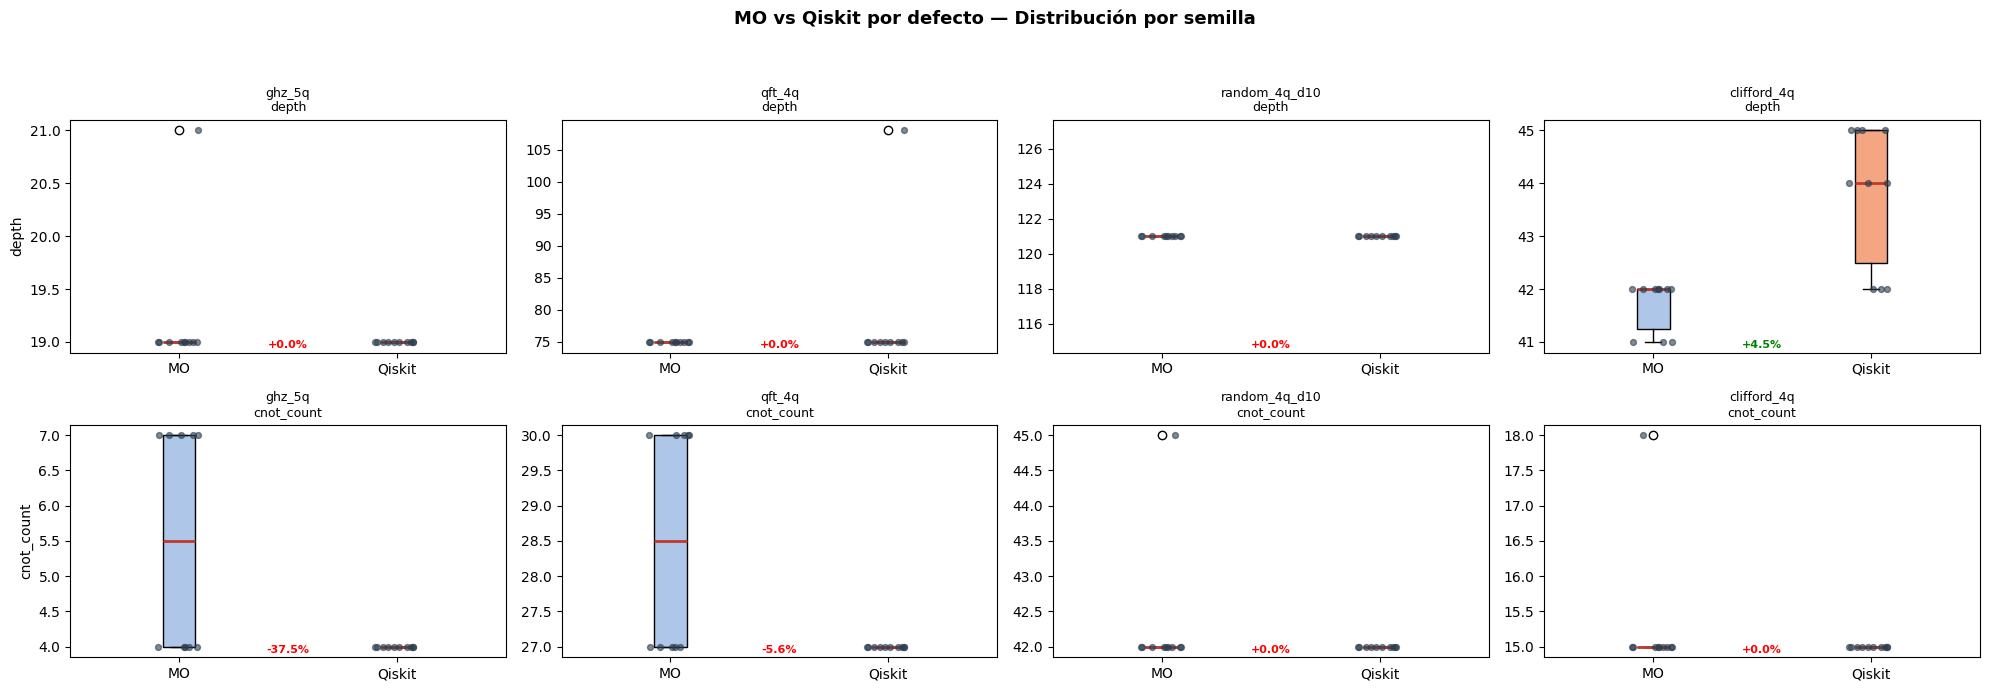

In [8]:
if _last_results is None:
    print('⚠ Ejecuta primero el benchmark.')
else:
    circuit_names = _last_results.circuit_names
    n_circuits    = len(circuit_names)
    obj_names     = _last_results.runs_for_circuit(circuit_names[0])[0].result.objective_names
    n_obj         = len(obj_names)

    fig, axes = plt.subplots(
        n_obj, n_circuits,
        figsize=(5 * n_circuits, 3.5 * n_obj),
        squeeze=False,
    )
    fig.suptitle('MO vs Qiskit por defecto — Distribución por semilla', fontsize=13, fontweight='bold')

    for ci, cname in enumerate(circuit_names):
        for oi, oname in enumerate(obj_names):
            ax = axes[oi][ci]

            # Valores MO (mejor del frente de Pareto por semilla)
            mo_values = _last_results.best_per_seed(cname, oi)

            # Valores Baseline
            bl = _last_baseline.get(cname, {}) if _last_baseline else {}
            bl_values = [v[oname] for v in bl.values()
                         if oname in v and v[oname] != float('inf')]

            data_to_plot = [mo_values, bl_values] if bl_values else [mo_values]
            labels = ['MO', 'Qiskit'] if bl_values else ['MO']
            colors = ['#aec6e8', '#f4a582']

            bp = ax.boxplot(data_to_plot, vert=True, patch_artist=True,
                            labels=labels,
                            medianprops=dict(color='#c0392b', linewidth=2))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)

            # Superponer puntos individuales
            rng = np.random.default_rng(0)
            for pos_idx, vals in enumerate(data_to_plot):
                jitter = rng.uniform(-0.1, 0.1, len(vals))
                ax.scatter([pos_idx + 1 + j for j in jitter], vals,
                           alpha=0.6, s=18, color='#2c3e50', zorder=3)

            ax.set_title(f'{cname}\n{oname}', fontsize=9)
            ax.set_ylabel(oname if ci == 0 else '')

            # Anotar mejora porcentual si hay baseline
            if bl_values and mo_values:
                mo_med = np.median(mo_values)
                bl_med = np.median(bl_values)
                if bl_med > 0:
                    pct = (bl_med - mo_med) / bl_med * 100
                    sign = '+' if pct >= 0 else ''
                    ax.annotate(f'{sign}{pct:.1f}%', xy=(0.5, 0.02),
                                xycoords='axes fraction', ha='center',
                                fontsize=8, color='green' if pct > 0 else 'red',
                                fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

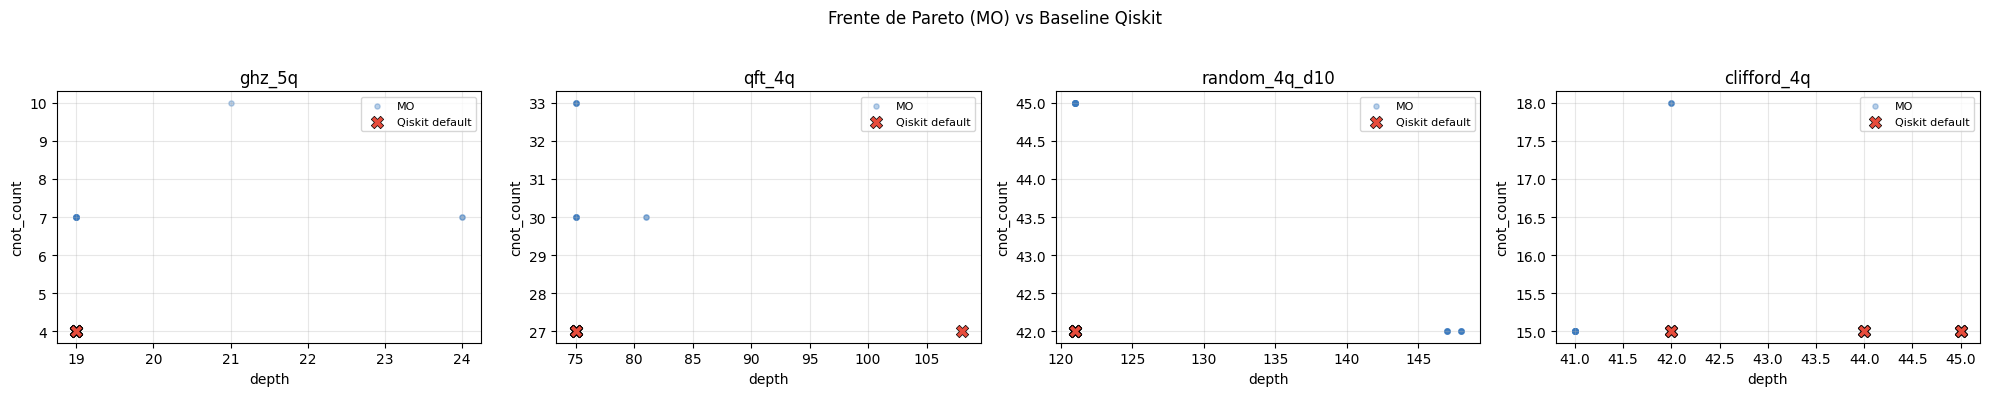

In [9]:
# Frente de Pareto por circuito + punto baseline de Qiskit
if _last_results is None:
    print('⚠ Ejecuta primero el benchmark.')
else:
    circuit_names = _last_results.circuit_names
    obj_names     = _last_results.runs_for_circuit(circuit_names[0])[0].result.objective_names

    fig, axes = plt.subplots(1, len(circuit_names), figsize=(5 * len(circuit_names), 4), squeeze=False)
    fig.suptitle('Frente de Pareto (MO) vs Baseline Qiskit', fontsize=12)

    for ci, cname in enumerate(circuit_names):
        ax = axes[0][ci]

        # Frente de Pareto del MO (todas las semillas)
        runs = _last_results.runs_for_circuit(cname)
        for run in runs:
            F = run.result.pareto_fitness
            if F is not None and len(F) > 0 and F.shape[1] >= 2:
                ax.scatter(F[:, 0], F[:, 1], alpha=0.35, s=14, color='#3a7abf',
                           label='MO' if run is runs[0] else None)

        # Puntos baseline de Qiskit (uno por semilla)
        bl = _last_baseline.get(cname, {}) if _last_baseline else {}
        if bl and len(obj_names) >= 2:
            bl_x = [v[obj_names[0]] for v in bl.values()
                    if obj_names[0] in v and v[obj_names[0]] != float('inf')]
            bl_y = [v[obj_names[1]] for v in bl.values()
                    if obj_names[1] in v and v[obj_names[1]] != float('inf')]
            if bl_x and bl_y:
                ax.scatter(bl_x, bl_y, marker='X', s=80, color='#e74c3c',
                           edgecolors='k', linewidths=0.5, zorder=5,
                           label='Qiskit default')

        ax.set_xlabel(obj_names[0])
        ax.set_ylabel(obj_names[1] if len(obj_names) > 1 else '')
        ax.set_title(cname)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

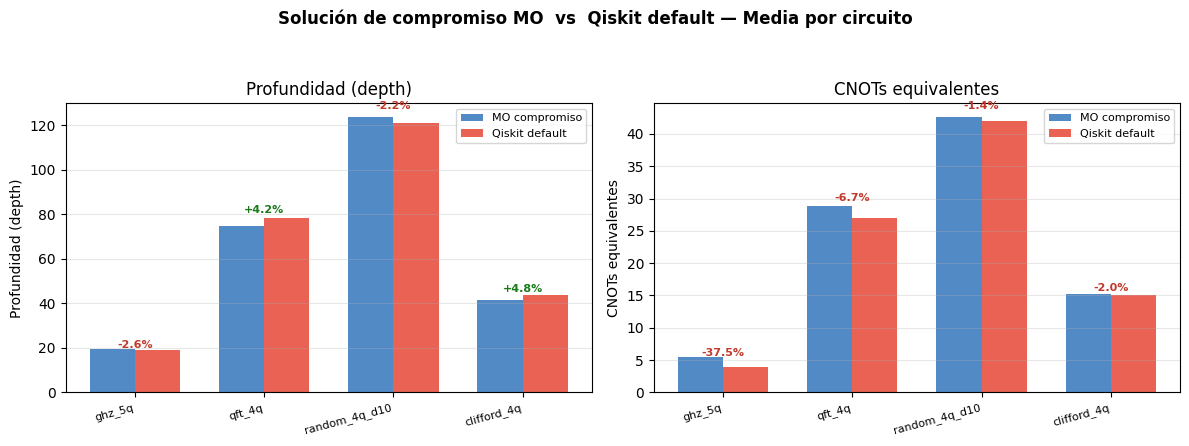

In [10]:
# ──────────────────────────────────────────────────────────────────────
#  Comparativa: solución de COMPROMISO del MO vs Qiskit default
#
#  La solución de compromiso es la que minimiza la distancia euclídea
#  al punto ideal (mejor en cada objetivo) en el espacio normalizado.
#  Es el candidato natural para desplegar en producción, a diferencia
#  del mejor-por-objetivo que nunca se usa como layout único.
# ──────────────────────────────────────────────────────────────────────
if _last_report is None or _last_baseline is None:
    print('⚠ Ejecuta primero el benchmark.')
else:
    OBJ_KEYS   = ['depth', 'cnot_count']
    OBJ_LABELS = {'depth': 'Profundidad (depth)', 'cnot_count': 'CNOTs equivalentes'}
    circuit_names_r = [ca.circuit_name for ca in _last_report.circuit_analyses]
    n_c = len(circuit_names_r)

    def _compromise_means(cname):
        """Media de la solución de compromiso sobre todas las semillas."""
        runs = _last_results.runs_for_circuit(cname)
        per_key = {k: [] for k in OBJ_KEYS}
        obj_names_local = runs[0].result.objective_names if runs else OBJ_KEYS
        for run in runs:
            F = run.result.pareto_fitness
            if F is None or len(F) == 0:
                continue
            f_min  = F.min(axis=0)
            f_max  = F.max(axis=0)
            f_range = np.where(f_max - f_min == 0, 1.0, f_max - f_min)
            F_norm  = (F - f_min) / f_range
            comp_idx = int(np.argmin(np.linalg.norm(F_norm, axis=1)))
            for ki, k in enumerate(OBJ_KEYS):
                if ki < F.shape[1]:
                    per_key[k].append(float(F[comp_idx, ki]))
        return {k: float(np.mean(v)) if v else 0.0 for k, v in per_key.items()}

    fig, axes = plt.subplots(1, len(OBJ_KEYS), figsize=(6 * len(OBJ_KEYS), 4.5), squeeze=False)
    fig.suptitle('Solución de compromiso MO  vs  Qiskit default — Media por circuito',
                 fontsize=12, fontweight='bold')

    x     = np.arange(n_c)
    width = 0.35

    for oi, okey in enumerate(OBJ_KEYS):
        ax = axes[0][oi]
        comp_means = []
        bl_means   = []
        for cname in circuit_names_r:
            comp_means.append(_compromise_means(cname).get(okey, 0))
            bl = _last_baseline.get(cname, {})
            vals = [v[okey] for v in bl.values() if v.get(okey, float('inf')) != float('inf')]
            bl_means.append(float(np.mean(vals)) if vals else 0.0)

        ax.bar(x - width/2, comp_means, width,
               label='MO compromiso', color='#3a7abf', alpha=0.88)
        ax.bar(x + width/2, bl_means,  width,
               label='Qiskit default', color='#e74c3c', alpha=0.88)

        ax.set_ylabel(OBJ_LABELS.get(okey, okey))
        ax.set_title(OBJ_LABELS.get(okey, okey))
        ax.set_xticks(x)
        ax.set_xticklabels(circuit_names_r, rotation=15, ha='right', fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

        for i, (mo_v, bl_v) in enumerate(zip(comp_means, bl_means)):
            if bl_v > 0:
                pct  = (bl_v - mo_v) / bl_v * 100
                sign = '+' if pct >= 0 else ''
                y_pos = max(mo_v, bl_v) * 1.03
                ax.text(i, y_pos, f'{sign}{pct:.1f}%', ha='center', fontsize=8,
                        color='#1a7a1a' if pct > 0 else '#c0392b', fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

---
## Análisis de dominancia

Una solución MO **domina** al punto de Qiskit si es ≤ en *todos* los objetivos  
(y estrictamente menor en al menos uno). Este porcentaje mide con qué frecuencia  
el MO encuentra al menos una solución del frente que supera a Qiskit simultáneamente  
en profundidad **y** CNOTs — que es la pregunta que realmente importa.

Circuito         Seeds dom.   Total      Tasa    bl_depth    bl_cnot  comment
────────────────────────────────────────────────────────────────────────────────
ghz_5q                    0      10      0.0%        19.0        4.0  ✗ MO nunca domina — Qiskit ya es óptimo
qft_4q                    1      10     10.0%        75.0       27.0  △ MO domina en algunos seeds
random_4q_d10             0      10      0.0%       121.0       42.0  ✗ MO nunca domina — Qiskit ya es óptimo
clifford_4q               6      10     60.0%        44.0       15.0  ✓ MO supera Qiskit la mayoría de veces



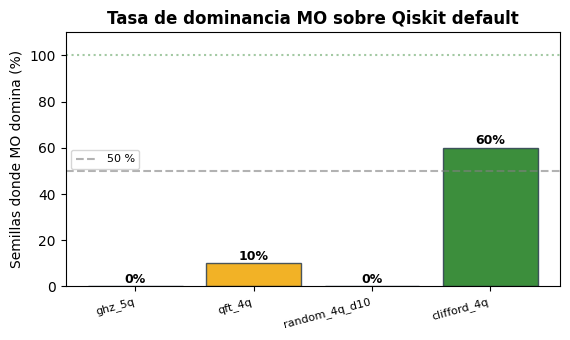

In [11]:
# ──────────────────────────────────────────────────────────────────────
#  Tasa de dominancia: % de semillas donde el MO domina al baseline
# ──────────────────────────────────────────────────────────────────────
if _last_results is None or _last_baseline is None:
    print('⚠ Ejecuta primero el benchmark.')
else:
    OBJ_KEYS_DOM = ['depth', 'cnot_count']

    def _dominates(F, bl_point):
        """True si alguna fila de F domina débilmente al punto bl_point
        (≤ en todos los objetivos, estrictamente < en al menos uno)."""
        bl_vec = np.array([bl_point.get(k, float('inf')) for k in OBJ_KEYS_DOM])
        weakly = np.all(F <= bl_vec[None, :], axis=1)
        strictly = np.any(F < bl_vec[None, :], axis=1)
        return bool(np.any(weakly & strictly))

    print(f"{'Circuito':<15}  {'Seeds dom.':>10}  {'Total':>6}  {'Tasa':>8}  "
          f"{'bl_depth':>10}  {'bl_cnot':>9}  {'comment'}")
    print('─' * 80)

    dom_rates = {}
    for cname in _last_results.circuit_names:
        runs = _last_results.runs_for_circuit(cname)
        bl_dict = _last_baseline.get(cname, {})
        dom_count = 0
        total = 0
        for run in runs:
            F = run.result.pareto_fitness
            if F is None or len(F) == 0:
                continue
            bl_pt = bl_dict.get(run.seed, {})
            if not bl_pt:
                continue
            total += 1
            if _dominates(F, bl_pt):
                dom_count += 1
        rate = dom_count / total * 100 if total > 0 else float('nan')
        dom_rates[cname] = rate

        bl_vals  = list(bl_dict.values())
        bl_d_med = np.median([v['depth'] for v in bl_vals if v['depth'] != float('inf')]) if bl_vals else float('nan')
        bl_c_med = np.median([v['cnot_count'] for v in bl_vals if v['cnot_count'] != float('inf')]) if bl_vals else float('nan')

        if rate >= 50:
            comment = '✓ MO supera Qiskit la mayoría de veces'
        elif rate > 0:
            comment = '△ MO domina en algunos seeds'
        else:
            comment = '✗ MO nunca domina — Qiskit ya es óptimo'

        print(f'{cname:<15}  {dom_count:>10}  {total:>6}  {rate:>7.1f}%  '
              f'{bl_d_med:>10.1f}  {bl_c_med:>9.1f}  {comment}')

    # Visualización: tasa de dominancia por circuito
    print()
    if dom_rates:
        fig, ax = plt.subplots(figsize=(max(4, len(dom_rates) * 1.2 + 1), 3.5))
        cnames_d = list(dom_rates.keys())
        rates_d  = [dom_rates[c] for c in cnames_d]
        colors_d = ['#1a7a1a' if r >= 50 else ('#f0a500' if r > 0 else '#c0392b') for r in rates_d]
        bars = ax.bar(cnames_d, rates_d, color=colors_d, edgecolor='#2c3e50', alpha=0.85)
        ax.axhline(50, color='gray', linestyle='--', alpha=0.6, label='50 %')
        ax.axhline(100, color='#1a7a1a', linestyle=':', alpha=0.4)
        ax.set_ylim(0, 110)
        ax.set_ylabel('Semillas donde MO domina (%)')
        ax.set_title('Tasa de dominancia MO sobre Qiskit default', fontweight='bold')
        ax.legend(fontsize=8)
        for bar, v in zip(bars, rates_d):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5,
                    f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
        plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)
        plt.tight_layout()
        plt.show()

---
## Tuning automático de hiperparámetros

Usa **Optuna (TPE)** para buscar la `OptimizerConfig` óptima que maximiza el **hipervolumen medio** del frente de Pareto.  
Configura el circuito de referencia y el presupuesto de búsqueda, luego ejecuta la celda de tuning.

> **Nota:** El tuning puede tardar varios minutos. Se recomienda usar circuitos pequeños (≤ 5 qubits) y un presupuesto moderado (10–30 trials).

In [ ]:
from src.mo_module.tuning import LayoutTuner, HyperparameterSpace
from src.mo_module.benchmark import DEFAULT_BENCHMARK_CIRCUITS

# ── Selección del circuito de referencia ──
TUNING_CIRCUIT_OPTIONS = [
    (f"{bc.name}  —  {bc.description}", bc.name)
    for bc in DEFAULT_BENCHMARK_CIRCUITS
]

tw_circuit = widgets.Dropdown(
    options=TUNING_CIRCUIT_OPTIONS,
    value=TUNING_CIRCUIT_OPTIONS[0][1],
    description='Circuito',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='480px'),
)

tw_backend = widgets.Dropdown(
    options=['fake_torino', 'fake_sherbrooke', 'fake_brisbane'],
    value='fake_torino',
    description='Backend',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='300px'),
)

tw_n_trials = widgets.IntSlider(
    value=15, min=5, max=60, step=5,
    description='Trials',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='380px'),
    continuous_update=False,
)
tw_n_trials_label = widgets.Label('evaluaciones Optuna (más = mejor búsqueda, más lento)')

tw_n_seeds = widgets.IntSlider(
    value=3, min=1, max=10, step=1,
    description='Seeds/trial',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='380px'),
    continuous_update=False,
)
tw_n_seeds_label = widgets.Label('seeds por trial (más = más robusto, más lento)')

# ── Espacio de búsqueda (rangos) ──
tw_pop_min = widgets.IntText(value=20, description='Pop min',
                             style={'description_width': '80px'},
                             layout=widgets.Layout(width='160px'))
tw_pop_max = widgets.IntText(value=80, description='Pop max',
                             style={'description_width': '80px'},
                             layout=widgets.Layout(width='160px'))
tw_gen_min = widgets.IntText(value=30, description='Gen min',
                             style={'description_width': '80px'},
                             layout=widgets.Layout(width='160px'))
tw_gen_max = widgets.IntText(value=120, description='Gen max',
                              style={'description_width': '80px'},
                              layout=widgets.Layout(width='160px'))

# ── Presupuesto proporcional ────────────────────────────────────────────────
# Mantiene pop_min × gen_min ≈ budget_min  (y lo mismo para _max)
# cuando el checkbox está activado. Así escalar la población reduce
# las generaciones para mantener el coste total de evaluaciones constante.
#
# Limitación: la relación real no es exactamente lineal (pymoo añade
# evaluaciones en la inicialización), y dentro de LayoutTuner los
# trials usan valores cappados (DEFAULT_EVAL_POP=30, DEFAULT_EVAL_GEN=50).
# El escalado afecta principalmente al rango de búsqueda y a la config final.
# ────────────────────────────────────────────────────────────────────────────
_budget_min = tw_pop_min.value * tw_gen_min.value   # initial: 20 × 30 = 600
_budget_max = tw_pop_max.value * tw_gen_max.value   # initial: 80 × 120 = 9600

tw_link_budget = widgets.Checkbox(
    value=False,
    description='Fijar presupuesto (pop × gen = cte)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px'),
)
tw_budget_min_label = widgets.Label(f'Budget min: {_budget_min}  evals')
tw_budget_max_label = widgets.Label(f'Budget max: {_budget_max}  evals')

_updating = [False]   # flag to avoid recursive callbacks

def _refresh_budget_labels():
    tw_budget_min_label.value = f'Budget min: {tw_pop_min.value * tw_gen_min.value}  evals'
    tw_budget_max_label.value = f'Budget max: {tw_pop_max.value * tw_gen_max.value}  evals'

def _on_pop_min_change(change):
    if _updating[0]:
        return
    _updating[0] = True
    if tw_link_budget.value and change['new'] > 0:
        new_gen = max(1, round(_budget_min / change['new']))
        tw_gen_min.value = new_gen
    _refresh_budget_labels()
    _updating[0] = False

def _on_pop_max_change(change):
    if _updating[0]:
        return
    _updating[0] = True
    if tw_link_budget.value and change['new'] > 0:
        new_gen = max(1, round(_budget_max / change['new']))
        tw_gen_max.value = new_gen
    _refresh_budget_labels()
    _updating[0] = False

def _on_gen_min_change(change):
    if _updating[0]:
        return
    _updating[0] = True
    if tw_link_budget.value and change['new'] > 0:
        new_pop = max(1, round(_budget_min / change['new']))
        tw_pop_min.value = new_pop
    _refresh_budget_labels()
    _updating[0] = False

def _on_gen_max_change(change):
    if _updating[0]:
        return
    _updating[0] = True
    if tw_link_budget.value and change['new'] > 0:
        new_pop = max(1, round(_budget_max / change['new']))
        tw_pop_max.value = new_pop
    _refresh_budget_labels()
    _updating[0] = False

def _on_link_toggle(change):
    global _budget_min, _budget_max
    if change['new']:   # just enabled → snapshot current budget
        _budget_min = tw_pop_min.value * tw_gen_min.value
        _budget_max = tw_pop_max.value * tw_gen_max.value
    _refresh_budget_labels()

tw_pop_min.observe(_on_pop_min_change, names='value')
tw_pop_max.observe(_on_pop_max_change, names='value')
tw_gen_min.observe(_on_gen_min_change, names='value')
tw_gen_max.observe(_on_gen_max_change, names='value')
tw_link_budget.observe(_on_link_toggle, names='value')

tw_objectives = widgets.SelectMultiple(
    options=['depth', 'cnot_count', 'error_rate', 'decoherence'],
    value=['depth', 'cnot_count'],
    description='Objetivos',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='300px', height='90px'),
)

tw_algorithms = widgets.SelectMultiple(
    options=['nsga2', 'moead'],
    value=['nsga2'],
    description='Algoritmos',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='220px', height='66px'),
)

# ── Layout del panel de tuning ──
tuning_panel = widgets.VBox([
    widgets.Label('── Configuración del Tuning ──'),
    widgets.HBox([tw_circuit, tw_backend]),
    widgets.HBox([tw_n_trials, tw_n_trials_label]),
    widgets.HBox([tw_n_seeds, tw_n_seeds_label]),
    widgets.Label('── Espacio de búsqueda (rangos para Optuna) ──'),
    widgets.HBox([tw_pop_min, tw_pop_max, tw_gen_min, tw_gen_max]),
    widgets.HBox([
        tw_link_budget,
        widgets.VBox([tw_budget_min_label, tw_budget_max_label]),
    ]),
    widgets.HBox([tw_objectives, tw_algorithms]),
], layout=widgets.Layout(border='1px solid #ddd', padding='12px', margin='8px 0'))

display(tuning_panel)
print('Configura los parámetros y ejecuta la celda siguiente ▼')

In [ ]:
# ── ▶ Ejecutar tuning ──
# Ejecuta esta celda (Shift+Enter) para lanzar el tuning.

import time as _time

_tuner = None

# Leer parámetros de los widgets
_tuning_circuit_name = tw_circuit.value
_tuning_backend_name = tw_backend.value
_tuning_objectives   = list(tw_objectives.value)
_tuning_algorithms   = list(tw_algorithms.value)

if not _tuning_objectives:
    print('⚠ Selecciona al menos un objetivo.')
elif not _tuning_algorithms:
    print('⚠ Selecciona al menos un algoritmo.')
else:
    from src.qiskit_interface.backend_info import get_backend as _get_backend

    _bc = next(bc for bc in DEFAULT_BENCHMARK_CIRCUITS if bc.name == _tuning_circuit_name)
    _circuit = _bc.create()
    _backend = _get_backend(_tuning_backend_name)

    _space = HyperparameterSpace(
        population_size_range=(tw_pop_min.value, tw_pop_max.value),
        n_generations_range=(tw_gen_min.value, tw_gen_max.value),
        algorithms=_tuning_algorithms,
    )

    _tuner = LayoutTuner(
        circuit=_circuit,
        backend=_backend,
        n_trials=tw_n_trials.value,
        n_seeds=tw_n_seeds.value,
        space=_space,
        objectives=_tuning_objectives,
        study_name=f'tuning_{_tuning_circuit_name}_{_tuning_backend_name}',
    )

    print(f'Iniciando tuning: {tw_n_trials.value} trials × {tw_n_seeds.value} seeds')
    print(f'Circuito: {_tuning_circuit_name}  |  Backend: {_tuning_backend_name}')
    print(f'Objetivos: {_tuning_objectives}  |  Algoritmos: {_tuning_algorithms}')
    print('=' * 60)

    _t0 = _time.perf_counter()
    _tuner.tune(show_progress_bar=True)
    _elapsed = _time.perf_counter() - _t0

    print(f'\n✓ Tuning completado en {_elapsed:.1f} s')
    print()
    print(_tuner.summary())

---
## Resultados del tuning

Visualización del historial de optimización y la mejor configuración encontrada.

In [ ]:
if _tuner is None:
    print('⚠ Ejecuta primero el tuning.')
else:
    try:
        import optuna.visualization as _vis
        _study = _tuner.study

        # Historia de optimización
        _fig_hist = _vis.plot_optimization_history(_study)
        _fig_hist.update_layout(title='Historial de optimización (HV medio)', height=400)
        _fig_hist.show()

        # Importancia de parámetros
        try:
            _fig_imp = _vis.plot_param_importances(_study)
            _fig_imp.update_layout(title='Importancia de hiperparámetros', height=350)
            _fig_imp.show()
        except Exception:
            print('(La importancia de parámetros requiere ≥ 4 trials completados)')

    except ImportError:
        print('(Instala plotly para ver las gráficas interactivas: pip install plotly)')

    # Mejor configuración
    _best = _tuner.best_config()
    print('\n── Mejor OptimizerConfig encontrada ──')
    print(f'  Algoritmo:           {_best.algorithm}')
    print(f'  Población:           {_best.population_size}')
    print(f'  Generaciones:        {_best.n_generations}')
    print(f'  Cruce:               {_best.crossover_operator}')
    print(f'  Prob. swap mut.:     {_best.prob_swap_mutation:.4f}')
    print(f'  Prob. replace mut.:  {_best.prob_replace_mutation:.4f}')
    print(f'  Objetivos:           {_best.objectives}')
    print()
    print('Para usar esta config en el benchmark, copia los valores al panel de arriba.')